# Volatility Prediction: Model Comparison

This notebook trains and compares models under the same expanding-window walk-forward, with every model held to a **matched naive baseline**, which predicts a regime whenever today's volatility already sits above the per-ticker expanding threshold that defines the label, a rule that uses only information available at time t. Two targets are evaluated, **NextVolSpike** (next-day, mostly a restatement of today's regime by construction, as the next section shows) and **FwdVolRegime** (the next 10 trading days, a window disjoint from the features, and the target the saved model uses).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.pipeline import load_data
from src.modeling import add_har_features, train_lightgbm, predict_with_model, evaluate_model
from src.split import generate_expanding_window_splits, get_fold_indices
from src.targets import add_regime_columns

sns.set_style("whitegrid")

CRIMSON, STEEL = "#DC143C", "#4682B4"
METRICS = ROOT / "reports" / "metrics"
FIGURES = ROOT / "reports" / "figures"

cfg = load_config()
features = cfg["data"]["features"]

df = load_data(str(ROOT / cfg["data"]["input_path"]))
df = add_regime_columns(add_har_features(df), forward_window=cfg["evaluation"]["forward_window"])
print(f"Rows: {len(df):,} | tickers: {df['Ticker'].nunique()}")

Rows: 37,002 | tickers: 14


## Why two targets

The next-day target mostly restates today's regime because of the correlation between the feature and the quantity the label is built on. `RollingVol(t)` (a feature) and the next-day `RollingVol(t+1)` (which drives the next-day label) share nine of ten days, so they are almost the same number. The forward target uses volatility over the next ten days, which shares no days with the feature window, so that correlation is much lower.

In [2]:
corr_nextday = df.groupby("Ticker").apply(
    lambda g: g["RollingVol"].corr(g["RollingVol"].shift(-1)), include_groups=False).mean()
corr_forward = df.groupby("Ticker").apply(
    lambda g: g["RollingVol"].corr(g["forward_vol"]), include_groups=False).mean()
print(f"corr(RollingVol_t, next-day RollingVol):     {corr_nextday:.3f}   (overlapping windows)")
print(f"corr(RollingVol_t, forward 10-day vol):      {corr_forward:.3f}   (disjoint windows)")
print(f"\nbase rate  NextVolSpike: {df['NextVolSpike'].mean():.3f}  |  FwdVolRegime: {df['FwdVolRegime'].mean():.3f}")

corr(RollingVol_t, next-day RollingVol):     0.957   (overlapping windows)
corr(RollingVol_t, forward 10-day vol):      0.471   (disjoint windows)

base rate  NextVolSpike: 0.252  |  FwdVolRegime: 0.254


## Walk-forward splits

Training is an expanding window. Each test window spans 63 trading days (about one quarter of market sessions) and starts on the first trading day after the training window, never overlapping another. A shorter final window is kept so the newest data is still evaluated. That partial window only carries next-day labels. The forward label needs 10 future trading days the sample does not yet have, so every FwdVolRegime row inside it is NaN and the forward target is evaluated on 28 folds whose last test window ends 2026-01-07, while NextVolSpike uses all 29. A trading-day-exact purge, applied inside `get_fold_indices`, drops any training row whose forward-label window would reach into the test period, so no label spans the train/test boundary (Lopez de Prado, 2018).

29 folds


/Users/tisyasharma/Projects/volatility-regime-forecasting/src/split.py:61: RuntimeWarning: Final fold is partial, 9 of 63 test days
  warnings.warn(


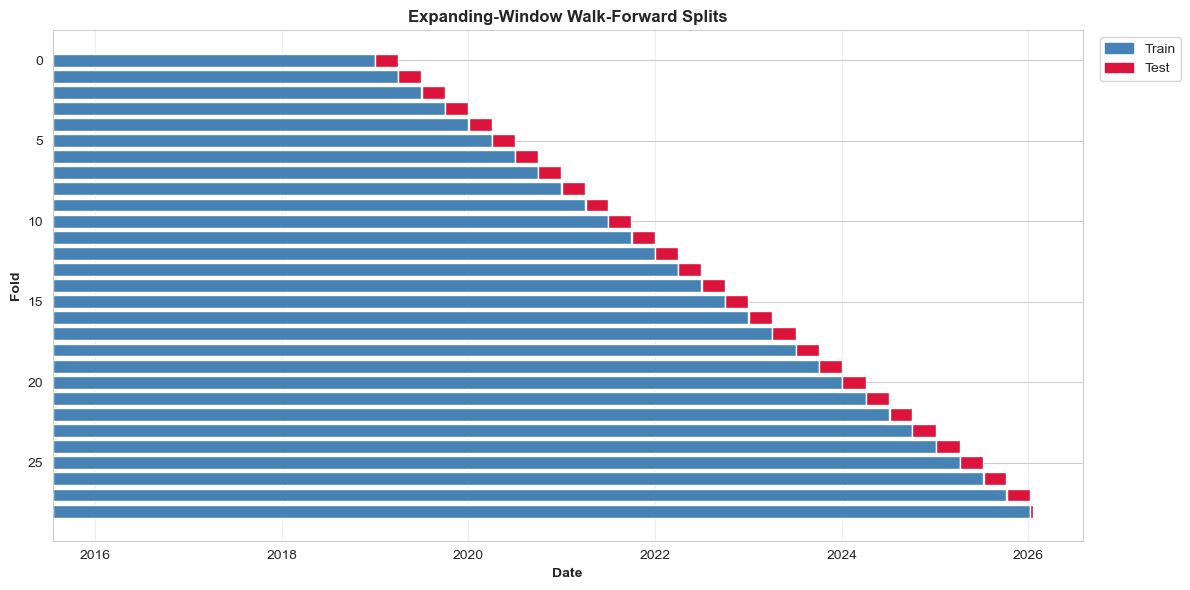

In [3]:
splits = generate_expanding_window_splits(
    dates=df["Date"],
    train_start=cfg["split"]["train_start"],
    initial_train_end=cfg["split"]["initial_train_end"],
    test_size_days=cfg["split"]["test_size_days"],
    step_size_days=cfg["split"]["step_size_days"],
    min_train_size_days=cfg["split"]["min_train_size_days"],
)
print(f"{len(splits)} folds")

fig, ax = plt.subplots(figsize=(12, 6))
for k, (tr_s, tr_e, te_s, te_e) in enumerate(splits):
    tr0, tr1 = mdates.date2num(pd.Timestamp(tr_s)), mdates.date2num(pd.Timestamp(tr_e))
    te0, te1 = mdates.date2num(pd.Timestamp(te_s)), mdates.date2num(pd.Timestamp(te_e))
    ax.barh(k, tr1 - tr0, left=tr0, color=STEEL, height=0.8)
    ax.barh(k, te1 - te0, left=te0, color=CRIMSON, height=0.8)
ax.xaxis_date()
ax.invert_yaxis()
ax.set_xlabel("Date", fontweight="bold")
ax.set_ylabel("Fold", fontweight="bold")
ax.set_title("Expanding-Window Walk-Forward Splits", fontweight="bold")
ax.legend(handles=[Patch(color=STEEL, label="Train"), Patch(color=CRIMSON, label="Test")],
          loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## One Model Across Folds

This section trains a single model (LightGBM) fold by fold on the forward target to show the walk-forward loop and the fold-to-fold variance directly, ahead of the full comparison.

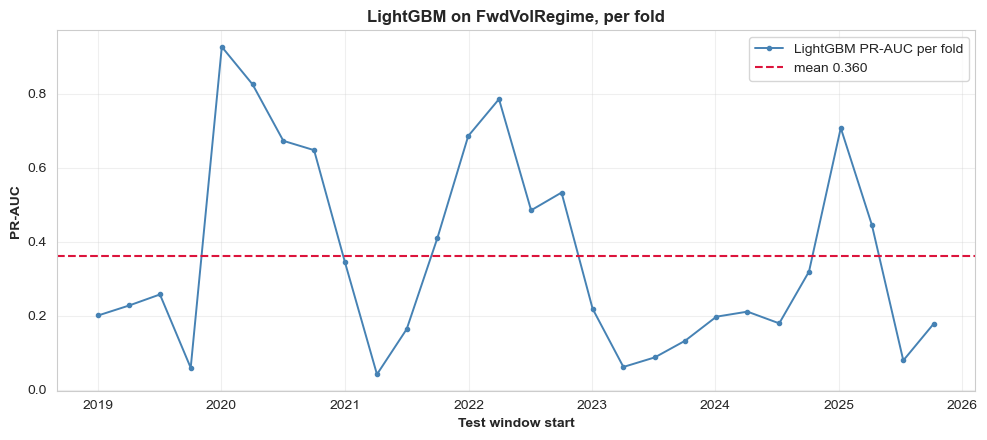

In [4]:
feat_ok = df[features].notna().all(axis=1)
target_ok = df["FwdVolRegime"].notna()

fold_rows = []
for i, (tr_s, tr_e, te_s, te_e) in enumerate(splits, 1):
    # label_end drives the horizon-exact purge inside get_fold_indices, so no training
    # row's 10-day label window reaches into the test period.
    tr_mask, te_mask = get_fold_indices(df["Date"], tr_s, tr_e, te_s, te_e,
                                        label_end=df["label_end_forward"])
    tr_mask = tr_mask & target_ok & feat_ok
    te_mask = te_mask & target_ok & feat_ok
    y_te = df.loc[te_mask, "FwdVolRegime"]
    if tr_mask.sum() < 50 or te_mask.sum() == 0 or y_te.nunique() < 2:
        continue
    model = train_lightgbm(df.loc[tr_mask, features], df.loc[tr_mask, "FwdVolRegime"],
                           **cfg["models"].get("lightgbm", {}))
    yp, pp = predict_with_model(model, df.loc[te_mask, features])
    fold_rows.append({"fold": i, "test_start": te_s, **evaluate_model(y_te, yp, pp)})

fold_df = pd.DataFrame(fold_rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(pd.to_datetime(fold_df["test_start"]), fold_df["pr_auc"], marker="o", markersize=3,
        color=STEEL, linewidth=1.4, label="LightGBM PR-AUC per fold")
ax.axhline(fold_df["pr_auc"].mean(), color=CRIMSON, linestyle="--",
           label=f"mean {fold_df['pr_auc'].mean():.3f}")
ax.set_xlabel("Test window start", fontweight="bold")
ax.set_ylabel("PR-AUC", fontweight="bold")
ax.set_title("LightGBM on FwdVolRegime, per fold", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Full Model Comparison

The evaluation driver (`scripts/run_evaluation.py`) runs every baseline and model through the same walk-forward on both targets and writes the metrics below.

NextVolSpike (mean across folds)


,model,precision_mean,recall_mean,f1_mean,pr_auc_mean
0,Majority,0.000,0.000,0.000,NaN
1,Persistence,0.599,0.627,0.601,NaN
2,MatchedNaive,0.871,0.875,0.873,0.901
3,HAR,0.874,0.868,0.871,0.901
4,LogisticRegression,0.524,0.838,0.631,0.676
5,LightGBM,0.520,0.888,0.639,0.705
6,XGBoost,0.560,0.842,0.657,0.710


FwdVolRegime (mean across folds)


,model,precision_mean,recall_mean,f1_mean,pr_auc_mean
0,Majority,0.000,0.000,0.000,NaN
1,Persistence,0.332,0.327,0.324,NaN
2,MatchedNaive,0.316,0.321,0.316,0.334
3,HAR,0.296,0.256,0.264,0.323
4,LogisticRegression,0.316,0.545,0.385,0.368
5,LightGBM,0.330,0.502,0.380,0.360
6,XGBoost,0.328,0.440,0.362,0.350


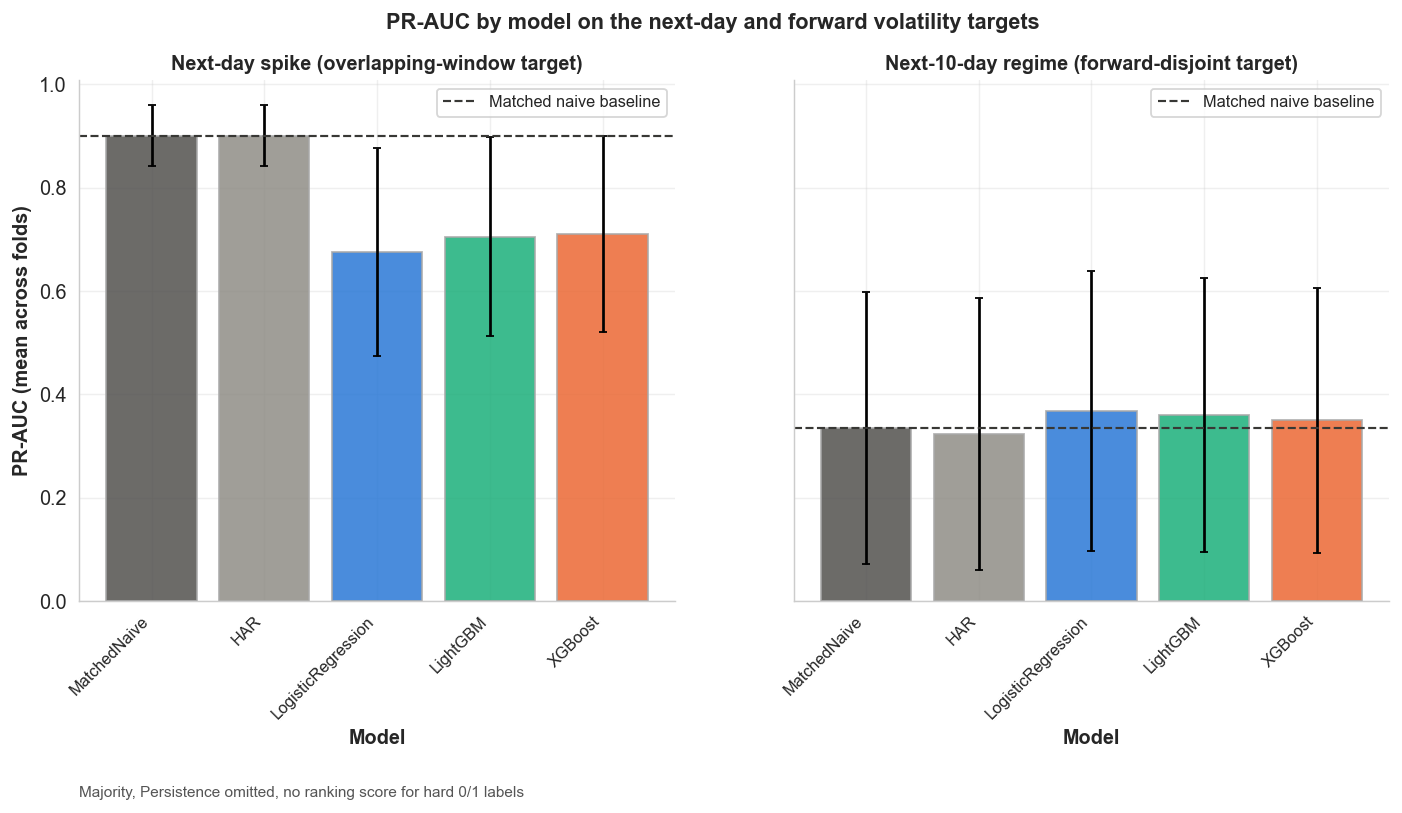

In [5]:
summary = pd.read_csv(METRICS / "walkforward_summary.csv")
order = ["Majority", "Persistence", "MatchedNaive", "HAR", "LogisticRegression", "LightGBM", "XGBoost"]
show = ["model", "precision_mean", "recall_mean", "f1_mean", "pr_auc_mean"]
for target in ["NextVolSpike", "FwdVolRegime"]:
    sub = summary[summary["target"] == target].set_index("model").reindex(order).reset_index()
    print(f"{target} (mean across folds)")
    display(sub[show].round(3))

display(Image(filename=str(FIGURES / "target_reversal.png")))

On the next-day target the matched naive rule (PR-AUC ~0.90) and HAR beat every learned model, and XGBoost (~0.71) scores below the matched naive rule. The matched naive rule reaching 0.90 against a no-skill floor near 0.27 shows the task mostly restates today's regime, which is why next-day results overstate the models.

On the forward-disjoint target the ordering reverses and all scores are lower. Every model drops toward the base rate because forecasting a ten-day-ahead regime is difficult, and here the learned models edge above the matched naive baseline, with the linear model slightly ahead of the gradient-boosted models. The gap is small, so the next section tests whether it is real.

## Dependence-Aware Significance Testing

Per-fold metrics are not independent. Volatility clusters in time and the tickers co-move, so treating the 28 folds as independent draws overstates confidence. Two bootstraps test each model against the matched naive baseline on the forward target. The fold-block bootstrap resamples the time-ordered folds and corrects for serial correlation. The date-block bootstrap resamples whole trading dates so the 14 co-moving tickers count as one cross-section, and it is the primary reading. A bootstrap CI entirely above 0 marks a reliable edge over the naive baseline, and one entirely below 0 marks a reliable deficit.

In [6]:
sig = pd.read_csv(METRICS / "significance.csv")
sig_xs = pd.read_csv(METRICS / "significance_crosssectional.csv")
print("Fold-block bootstrap (serial correlation only)")
display(sig)
print("Date-block bootstrap (cross-sectional, primary)")
display(sig_xs)

Fold-block bootstrap (serial correlation only)


,target,metric,model,vs,mean_diff,n_folds,fold_autocorr,n_eff,t_naive,t_effN,block_boot_ci_lo,block_boot_ci_hi,block_boot_p
0,FwdVolRegime,pr_auc,LogisticRegression,MatchedNaive,0.0335,28,0.138,21.2,3.07,2.67,0.0136,0.0605,0.0022
1,FwdVolRegime,pr_auc,LightGBM,MatchedNaive,0.0262,28,0.317,14.5,2.23,1.61,0.0019,0.0596,0.0358
2,FwdVolRegime,pr_auc,XGBoost,MatchedNaive,0.0156,28,0.321,14.4,1.27,0.91,-0.0139,0.0522,0.2301
3,FwdVolRegime,pr_auc,HAR,MatchedNaive,-0.0116,28,0.123,21.9,-2.10,-1.85,-0.0219,-0.0006,0.0395


Date-block bootstrap (cross-sectional, primary)


,target,metric,model,vs,method,edge,ci_lo,ci_hi,p,n_dates,n_rows,n_boot
0,FwdVolRegime,pr_auc,LogisticRegression,MatchedNaive,date_block,0.0335,0.0093,0.0474,0.0093,1763,24682,3000
1,FwdVolRegime,pr_auc,LightGBM,MatchedNaive,date_block,0.0262,0.0013,0.0452,0.0420,1763,24682,3000
2,FwdVolRegime,pr_auc,XGBoost,MatchedNaive,date_block,0.0156,-0.0082,0.0331,0.2047,1763,24682,3000
3,FwdVolRegime,pr_auc,HAR,MatchedNaive,date_block,-0.0116,-0.0251,0.0023,0.1033,1763,24682,3000


On the forward target the linear model clears the significance bar with +0.034 PR-AUC over the matched naive baseline. The fold-block bootstrap puts the 95% CI at [0.014, 0.061], p=0.002, and the cross-sectional date-block bootstrap, which counts the co-moving tickers as one cross-section, holds it at [0.009, 0.047], p=0.009. LightGBM slips to borderline under the date-block test (p=0.042), XGBoost does not clear it (p=0.20), and the small HAR deficit is no longer significant (p=0.10). A Holm correction across the three learned models leaves the linear result significant under both, at date-block p=0.028, so the logistic regression is the only model whose edge survives once the cross-section is counted.

## Reproduce

```bash
python scripts/run_evaluation.py    # both targets, all models, writes reports/metrics/
python scripts/significance.py      # dependence-aware significance testing
python scripts/make_figures.py      # figures
```